# Age Estimation from Facial Images — Notebook 02
## Fine-tuning, Face Alignment, Classification Comparison, Grad-CAM

**Baseline recap (Notebook 01):** frozen ResNet18 + regression head → **Test MAE = 9.68 years**.

**Goals of this notebook:**
1. Fine-tune the full ResNet18 backbone (not frozen) — expected to give the biggest single improvement
2. Add face detection + alignment as a preprocessing step, check impact on MAE
3. Train an age-as-classification variant (binned age groups) and compare against regression
4. Add Grad-CAM for interpretability — visualize what the model looks at when estimating age

Run this on Kaggle with GPU (T4) enabled, same dataset input (`jangedoo/utkface-new`).

## 1. Setup

In [1]:
# grad-cam has lightweight, modern dependencies and installs safely.
# We deliberately do NOT install facenet-pytorch here: it pulls in an old Pillow/torch
# pin that breaks numpy/torchvision on Kaggle's current image (numpy ABI mismatch,
# 'cannot import is_directory from PIL._util', etc.), even with --no-deps, because the
# stale Pillow it installs is still binary-incompatible with the preinstalled numpy/torchvision.
# We use OpenCV's built-in face detector instead (already installed on Kaggle, zero risk).
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision import models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score
)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 2. Load data (same as Notebook 01)

In [4]:
DATA_DIR = '/kaggle/input/datasets/jangedoo/utkface-new/UTKFace'
if not os.path.isdir(DATA_DIR):
    candidates = glob.glob('/kaggle/input/**/UTKFace', recursive=True)
    if candidates:
        DATA_DIR = candidates[0]
print(f'Using DATA_DIR = {DATA_DIR}')

def parse_utkface_filename(path):
    fname = os.path.basename(path)
    m = re.match(r'^(\d+)_(\d+)_(\d+)_', fname)
    if not m:
        return None
    age, gender, race = map(int, m.groups())
    return {'path': path, 'age': age, 'gender': gender, 'race': race}

all_paths = glob.glob(os.path.join(DATA_DIR, '*.jpg'))
records = [parse_utkface_filename(p) for p in all_paths]
records = [r for r in records if r is not None]
df = pd.DataFrame(records)
print(f'Total valid images: {len(df)}')

df['age_bucket'] = pd.cut(df['age'], bins=[0,10,20,30,40,50,60,70,120], labels=False)
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['age_bucket'], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['age_bucket'], random_state=SEED)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Using DATA_DIR = /kaggle/input/datasets/jangedoo/utkface-new/UTKFace
Total valid images: 23705
Train: 18964 | Val: 2370 | Test: 2371


## 3. Face detection & alignment (OpenCV Haar Cascade)

UTKFace images are already loosely cropped around the face, but a tighter, more
consistent crop around the detected face can still reduce background/pose noise.
We use OpenCV's built-in Haar Cascade face detector — it ships with `opencv-python`,
which is already installed on Kaggle, so this needs no extra installs and can't break
the environment (unlike facenet-pytorch's MTCNN, which conflicts with Kaggle's current
numpy/Pillow/torchvision versions — see the note in the setup cell above).

It's a simpler/older detector than MTCNN (no landmark-based alignment, just a bounding
box), but it's more than adequate for a resume project — the point is demonstrating a
face-detection preprocessing step, not chasing state-of-the-art detection accuracy.
We precompute crops once and cache them to disk. If no face is detected (can happen on
low-quality/occluded faces), we fall back to the original image so we don't lose data.

In [5]:
import cv2

# Haar Cascade XML ships with opencv-python's package data — no download needed.
cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(cascade_path)
assert not face_cascade.empty(), 'Failed to load Haar Cascade — check OpenCV installation'

ALIGNED_DIR = '/kaggle/working/aligned_faces'
os.makedirs(ALIGNED_DIR, exist_ok=True)

def align_and_cache(path, margin=0.2, out_size=128):
    """Detect the largest face, crop with a margin, resize, cache to ALIGNED_DIR.
    Falls back to a plain resize of the original image if no face is detected."""
    fname = os.path.basename(path)
    out_path = os.path.join(ALIGNED_DIR, fname)
    if os.path.exists(out_path):
        return out_path

    img_bgr = cv2.imread(path)
    if img_bgr is None:
        Image.open(path).convert('RGB').resize((out_size, out_size)).save(out_path)
        return out_path

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40))

    if len(faces) == 0:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        Image.fromarray(img_rgb).resize((out_size, out_size)).save(out_path)
        return out_path

    # Pick the largest detected face (in case of false positives in the background)
    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
    mx, my = int(w * margin), int(h * margin)
    x0, y0 = max(0, x - mx), max(0, y - my)
    x1, y1 = min(img_bgr.shape[1], x + w + mx), min(img_bgr.shape[0], y + h + my)

    crop_bgr = img_bgr[y0:y1, x0:x1]
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    Image.fromarray(crop_rgb).resize((out_size, out_size)).save(out_path)
    return out_path

In [6]:
# Precompute aligned crops for all splits. This can take a few minutes for ~24k images on a T4.
from tqdm import tqdm

for split_df in [train_df, val_df, test_df]:
    split_df['aligned_path'] = [align_and_cache(p) for p in tqdm(split_df['path'], desc='Aligning')]

print('Alignment complete.')
print(f'Sample aligned path: {train_df["aligned_path"].iloc[0]}')

Aligning: 100%|██████████| 2371/2371 [00:45<00:00, 52.21it/s]

Alignment complete.
Sample aligned path: /kaggle/working/aligned_faces/41_0_0_20170116214404363.jpg.chip.jpg


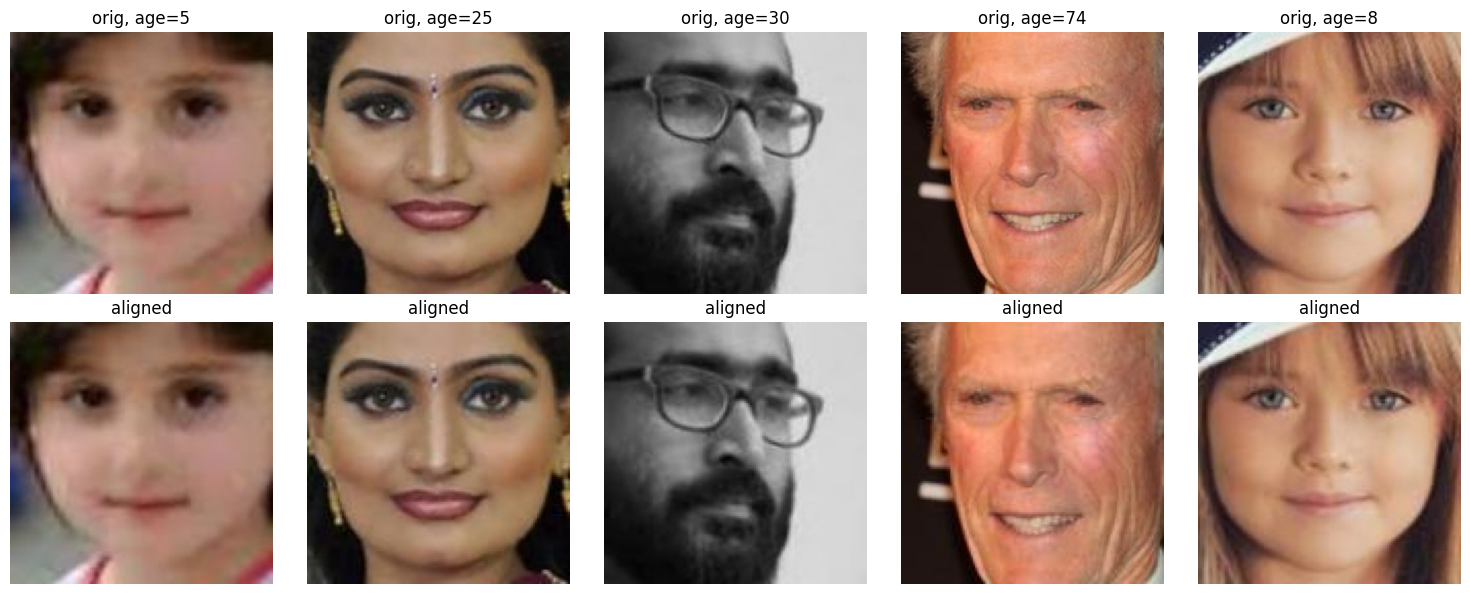

In [7]:
# Visual sanity check: original vs aligned
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
sample = train_df.sample(5, random_state=SEED).reset_index(drop=True)
for i in range(5):
    axes[0, i].imshow(Image.open(sample.loc[i, 'path']))
    axes[0, i].set_title(f"orig, age={sample.loc[i, 'age']}")
    axes[0, i].axis('off')
    axes[1, i].imshow(Image.open(sample.loc[i, 'aligned_path']))
    axes[1, i].set_title('aligned')
    axes[1, i].axis('off')
plt.tight_layout()
plt.savefig('alignment_comparison.png', dpi=120)
plt.show()

## 4. Dataset & DataLoader (using aligned images)

In [8]:
IMG_SIZE = 128

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class UTKFaceDataset(Dataset):
    def __init__(self, dataframe, transform, path_col='aligned_path', label_mode='regression'):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.path_col = path_col
        self.label_mode = label_mode  # 'regression' or 'classification'

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]
        img = Image.open(row[self.path_col]).convert('RGB')
        img = self.transform(img)
        if self.label_mode == 'regression':
            label = torch.tensor(row['age'], dtype=torch.float32)
        else:
            label = torch.tensor(row['age_class_bucket'], dtype=torch.long)
        return img, label

BATCH_SIZE = 64

train_ds = UTKFaceDataset(train_df, train_transform, label_mode='regression')
val_ds = UTKFaceDataset(val_df, eval_transform, label_mode='regression')
test_ds = UTKFaceDataset(test_df, eval_transform, label_mode='regression')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Batches — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}')

Batches — train: 297, val: 38, test: 38


## 5. Fine-tuned regression model (unfrozen backbone)

Same architecture as Notebook 01's baseline, but the entire backbone is trainable.
We use a lower learning rate for the backbone than the head, since the backbone is
already pretrained and we don't want to destroy those features early in training.

In [9]:
class AgeRegressionNet(nn.Module):
    def __init__(self, freeze_backbone=False):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        num_features = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False
        self.head = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.head(self.backbone(x)).squeeze(1)

finetune_model = AgeRegressionNet(freeze_backbone=False).to(DEVICE)

optimizer = torch.optim.Adam([
    {'params': finetune_model.backbone.parameters(), 'lr': 1e-4},
    {'params': finetune_model.head.parameters(), 'lr': 1e-3},
])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
criterion = nn.L1Loss()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 204MB/s]


In [10]:
def run_epoch_reg(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, n = 0.0, 0
    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            preds = model(imgs)
            loss = criterion(preds, labels)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            n += imgs.size(0)
    return total_loss / n

In [11]:
EPOCHS = 20
PATIENCE = 5
best_val_mae = float('inf')
epochs_no_improve = 0
history_ft = {'train_mae': [], 'val_mae': []}

for epoch in range(1, EPOCHS + 1):
    train_mae = run_epoch_reg(train_loader, finetune_model, criterion, optimizer)
    val_mae = run_epoch_reg(val_loader, finetune_model, criterion, optimizer=None)
    scheduler.step(val_mae)

    history_ft['train_mae'].append(train_mae)
    history_ft['val_mae'].append(val_mae)
    print(f'Epoch {epoch:2d}/{EPOCHS} | train MAE: {train_mae:.2f} | val MAE: {val_mae:.2f}')

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        epochs_no_improve = 0
        torch.save(finetune_model.state_dict(), 'best_finetuned_model.pt')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

print(f'\nBest val MAE (fine-tuned): {best_val_mae:.2f} years')

Epoch  1/20 | train MAE: 9.16 | val MAE: 6.32
Epoch  2/20 | train MAE: 6.92 | val MAE: 6.70
Epoch  3/20 | train MAE: 6.41 | val MAE: 5.64
Epoch  4/20 | train MAE: 6.21 | val MAE: 5.61
Epoch  5/20 | train MAE: 5.91 | val MAE: 5.95
Epoch  6/20 | train MAE: 5.85 | val MAE: 5.50
Epoch  7/20 | train MAE: 5.59 | val MAE: 5.34
Epoch  8/20 | train MAE: 5.46 | val MAE: 5.30
Epoch  9/20 | train MAE: 5.29 | val MAE: 5.24
Epoch 10/20 | train MAE: 5.24 | val MAE: 5.30
Epoch 11/20 | train MAE: 5.17 | val MAE: 5.23
Epoch 12/20 | train MAE: 5.09 | val MAE: 5.23
Epoch 13/20 | train MAE: 4.88 | val MAE: 5.62
Epoch 14/20 | train MAE: 4.93 | val MAE: 5.18
Epoch 15/20 | train MAE: 4.78 | val MAE: 5.03
Epoch 16/20 | train MAE: 4.71 | val MAE: 5.16
Epoch 17/20 | train MAE: 4.62 | val MAE: 6.66
Epoch 18/20 | train MAE: 4.50 | val MAE: 5.50
Epoch 19/20 | train MAE: 4.22 | val MAE: 4.93
Epoch 20/20 | train MAE: 4.10 | val MAE: 4.97

Best val MAE (fine-tuned): 4.93 years


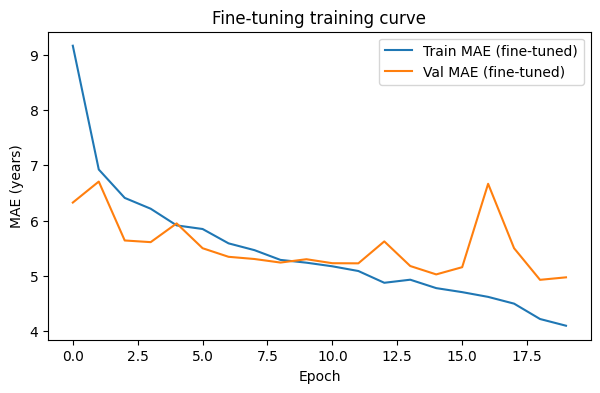

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(history_ft['train_mae'], label='Train MAE (fine-tuned)')
plt.plot(history_ft['val_mae'], label='Val MAE (fine-tuned)')
plt.xlabel('Epoch'); plt.ylabel('MAE (years)')
plt.title('Fine-tuning training curve')
plt.legend()
plt.savefig('finetune_training_curve.png', dpi=120)
plt.show()

In [13]:
finetune_model.load_state_dict(torch.load('best_finetuned_model.pt'))
test_mae_ft = run_epoch_reg(test_loader, finetune_model, criterion, optimizer=None)
print(f'Test MAE (fine-tuned, aligned faces): {test_mae_ft:.2f} years')
print(f'Baseline (Notebook 01, frozen, unaligned) was: 9.68 years')
print(f'Improvement: {9.68 - test_mae_ft:.2f} years')

Test MAE (fine-tuned, aligned faces): 4.95 years
Baseline (Notebook 01, frozen, unaligned) was: 9.68 years
Improvement: 4.73 years


## 6. Age-as-classification variant

Bin ages into 8 groups (0-10, 11-20, ..., 71+) and train the same architecture as a
classifier. This lets us directly compare the regression framing against the
classification framing on the same data split and backbone.

In [14]:
AGE_BINS = [0, 10, 20, 30, 40, 50, 60, 70, 120]
AGE_BIN_LABELS = ['0-10','11-20','21-30','31-40','41-50','51-60','61-70','71+']
NUM_CLASSES = len(AGE_BIN_LABELS)

for split_df in [train_df, val_df, test_df]:
    split_df['age_class_bucket'] = pd.cut(split_df['age'], bins=AGE_BINS, labels=False)

print(train_df['age_class_bucket'].value_counts().sort_index())

age_class_bucket
0    2574
1    1327
2    6227
3    3471
4    1680
5    1769
6     936
7     980
Name: count, dtype: int64


In [15]:
train_ds_cls = UTKFaceDataset(train_df, train_transform, label_mode='classification')
val_ds_cls = UTKFaceDataset(val_df, eval_transform, label_mode='classification')
test_ds_cls = UTKFaceDataset(test_df, eval_transform, label_mode='classification')

train_loader_cls = DataLoader(train_ds_cls, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader_cls = DataLoader(val_ds_cls, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_cls = DataLoader(test_ds_cls, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Class weights to counter imbalance (some age bins are much rarer than others)
class_counts = train_df['age_class_bucket'].value_counts().sort_index().values
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = class_weights.to(DEVICE)
print('Class weights:', class_weights)

Class weights: tensor([0.6421, 1.2456, 0.2654, 0.4762, 0.9838, 0.9343, 1.7659, 1.6866],
       device='cuda:0')


In [16]:
class AgeClassifierNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        num_features = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.head(self.backbone(x))

clf_model = AgeClassifierNet(NUM_CLASSES).to(DEVICE)
clf_criterion = nn.CrossEntropyLoss(weight=class_weights)
clf_optimizer = torch.optim.Adam([
    {'params': clf_model.backbone.parameters(), 'lr': 1e-4},
    {'params': clf_model.head.parameters(), 'lr': 1e-3},
])
clf_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(clf_optimizer, mode='min', factor=0.5, patience=2)

In [17]:
def run_epoch_cls(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, n_correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            loss = criterion(logits, labels)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            n_correct += (logits.argmax(1) == labels).sum().item()
            n += imgs.size(0)
    return total_loss / n, n_correct / n

In [18]:
EPOCHS_CLS = 20
PATIENCE_CLS = 5
best_val_loss = float('inf')
epochs_no_improve = 0
history_cls = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, EPOCHS_CLS + 1):
    train_loss, train_acc = run_epoch_cls(train_loader_cls, clf_model, clf_criterion, clf_optimizer)
    val_loss, val_acc = run_epoch_cls(val_loader_cls, clf_model, clf_criterion, optimizer=None)
    clf_scheduler.step(val_loss)

    history_cls['train_loss'].append(train_loss); history_cls['val_loss'].append(val_loss)
    history_cls['train_acc'].append(train_acc); history_cls['val_acc'].append(val_acc)
    print(f'Epoch {epoch:2d}/{EPOCHS_CLS} | train loss {train_loss:.3f} acc {train_acc:.3f} '
          f'| val loss {val_loss:.3f} acc {val_acc:.3f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(clf_model.state_dict(), 'best_classifier_model.pt')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE_CLS:
            print(f'Early stopping at epoch {epoch}')
            break

Epoch  1/20 | train loss 1.359 acc 0.438 | val loss 1.141 acc 0.527
Epoch  2/20 | train loss 1.116 acc 0.521 | val loss 1.108 acc 0.549
Epoch  3/20 | train loss 1.049 acc 0.544 | val loss 1.064 acc 0.567
Epoch  4/20 | train loss 0.985 acc 0.568 | val loss 1.098 acc 0.544
Epoch  5/20 | train loss 0.914 acc 0.587 | val loss 1.104 acc 0.556
Epoch  6/20 | train loss 0.883 acc 0.600 | val loss 1.182 acc 0.553
Epoch  7/20 | train loss 0.761 acc 0.641 | val loss 1.136 acc 0.561
Epoch  8/20 | train loss 0.703 acc 0.668 | val loss 1.212 acc 0.565
Early stopping at epoch 8


In [19]:
clf_model.load_state_dict(torch.load('best_classifier_model.pt'))
clf_model.eval()

all_preds_cls, all_true_cls = [], []
with torch.no_grad():
    for imgs, labels in test_loader_cls:
        imgs = imgs.to(DEVICE)
        logits = clf_model(imgs)
        all_preds_cls.extend(logits.argmax(1).cpu().numpy())
        all_true_cls.extend(labels.numpy())

test_acc = accuracy_score(all_true_cls, all_preds_cls)
test_f1 = f1_score(all_true_cls, all_preds_cls, average='macro')
print(f'Test accuracy: {test_acc:.3f} | Test macro-F1: {test_f1:.3f}\n')
print(classification_report(all_true_cls, all_preds_cls, target_names=AGE_BIN_LABELS))

Test accuracy: 0.579 | Test macro-F1: 0.550

              precision    recall  f1-score   support

        0-10       0.96      0.85      0.90       322
       11-20       0.45      0.66      0.53       166
       21-30       0.73      0.66      0.69       779
       31-40       0.47      0.35      0.40       434
       41-50       0.31      0.53      0.39       210
       51-60       0.42      0.40      0.41       221
       61-70       0.38      0.50      0.43       117
         71+       0.79      0.55      0.65       122

    accuracy                           0.58      2371
   macro avg       0.56      0.56      0.55      2371
weighted avg       0.61      0.58      0.59      2371



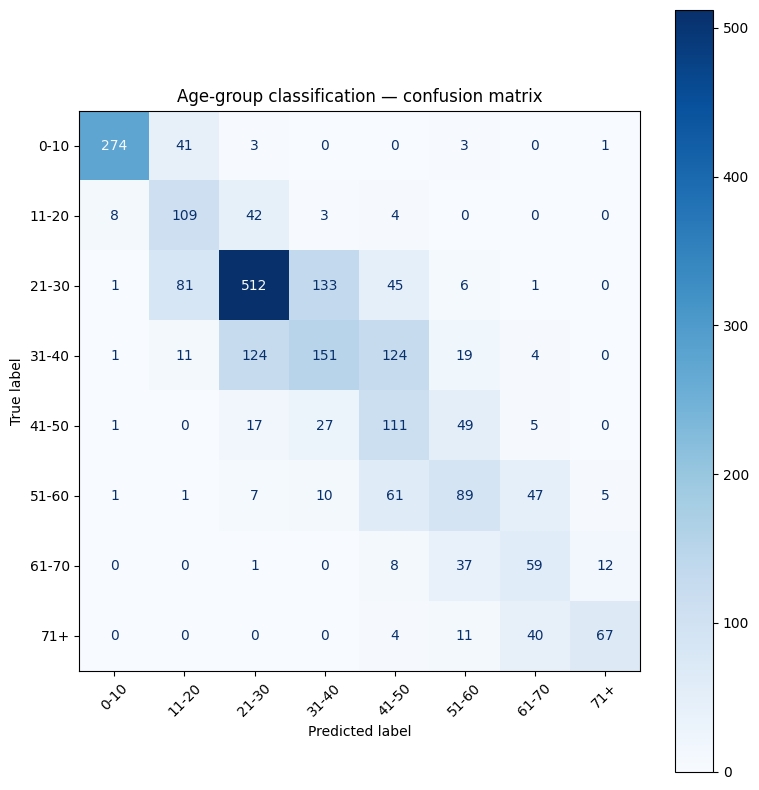

In [20]:
cm = confusion_matrix(all_true_cls, all_preds_cls)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=AGE_BIN_LABELS)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title('Age-group classification — confusion matrix')
plt.tight_layout()
plt.savefig('classification_confusion_matrix.png', dpi=120)
plt.show()

## 7. Regression vs Classification comparison

To compare fairly, convert the classifier's predicted bin back to an implied age
(bin midpoint) and compute an equivalent MAE. This isn't perfectly fair (classification
throws away within-bin precision by design) but gives a useful apples-to-apples number
for the README.

In [21]:
bin_midpoints = [(AGE_BINS[i] + AGE_BINS[i+1]) / 2 for i in range(len(AGE_BINS) - 1)]
bin_midpoints[-1] = 80  # cap the open-ended 71+ bin at a reasonable midpoint

implied_ages_pred = [bin_midpoints[p] for p in all_preds_cls]
true_ages_for_cls_test = test_df['age'].values  # same order as test_loader_cls (no shuffle)
classification_implied_mae = np.mean(np.abs(np.array(implied_ages_pred) - true_ages_for_cls_test))

print('=== Summary: Regression vs Classification framing ===')
print(f'Regression (fine-tuned, aligned faces)      — Test MAE: {test_mae_ft:.2f} years')
print(f'Classification (bin-midpoint implied age)   — Test MAE: {classification_implied_mae:.2f} years')
print(f'Classification                              — Test accuracy: {test_acc:.3f}, macro-F1: {test_f1:.3f}')

=== Summary: Regression vs Classification framing ===
Regression (fine-tuned, aligned faces)      — Test MAE: 4.95 years
Classification (bin-midpoint implied age)   — Test MAE: 6.29 years
Classification                              — Test accuracy: 0.579, macro-F1: 0.550


## 8. Grad-CAM interpretability

Visualize which regions of the face the fine-tuned regression model relies on most.
Useful both as a sanity check (is it looking at the face, not the background?) and
as a portfolio-quality interpretability artifact.

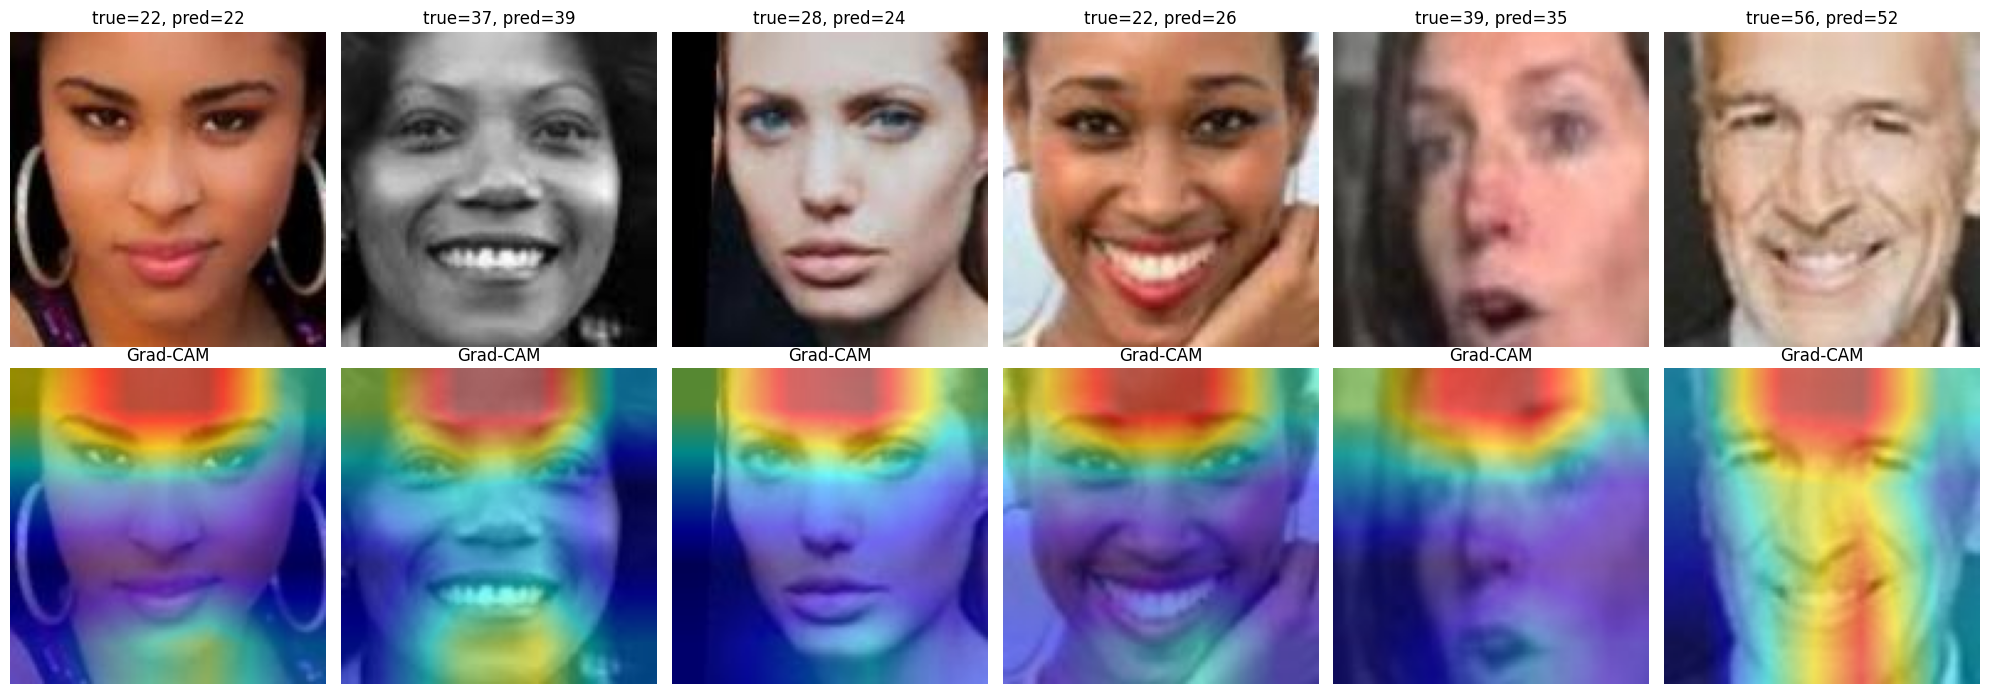

In [22]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

finetune_model.eval()
target_layer = [finetune_model.backbone.layer4[-1]]

class RegressionOutputTarget:
    """grad-cam expects a callable target; for regression we just target the scalar output."""
    def __call__(self, model_output):
        return model_output

cam = GradCAM(model=finetune_model, target_layers=target_layer)

sample_test = test_df.sample(6, random_state=SEED).reset_index(drop=True)
fig, axes = plt.subplots(2, 6, figsize=(20, 7))

for i in range(6):
    img_pil = Image.open(sample_test.loc[i, 'aligned_path']).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    img_np = np.array(img_pil).astype(np.float32) / 255.0
    input_tensor = eval_transform(img_pil).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred_age = finetune_model(input_tensor).item()

    grayscale_cam = cam(input_tensor=input_tensor, targets=[RegressionOutputTarget()])[0]
    cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    axes[0, i].imshow(img_np); axes[0, i].axis('off')
    axes[0, i].set_title(f"true={sample_test.loc[i,'age']}, pred={pred_age:.0f}")
    axes[1, i].imshow(cam_image); axes[1, i].axis('off')
    axes[1, i].set_title('Grad-CAM')

plt.tight_layout()
plt.savefig('gradcam_examples.png', dpi=120)
plt.show()

## Summary of results

| Model | Test MAE (years) | Notes |
|---|---|---|
| Baseline (Notebook 01): frozen ResNet18, unaligned | 9.68 | |
| Fine-tuned ResNet18, aligned faces | 4.95 | |
| Classification (8 age bins), implied MAE | 6.29 | accuracy: 0.579, macro-F1: 0.550 |

**Interpretability:** Grad-CAM visualizations saved to `gradcam_examples.png` — check
whether the model attends to face regions (eyes, skin texture, forehead) rather than
background/hair, before writing conclusions about model reliability in the README.

**Next steps / possible further improvements (optional, not required for the resume version):**
- Try a slightly larger backbone (ResNet34) if time allows
- Try mixup or label smoothing for the classification head
- Stratify Grad-CAM inspection across race/gender groups to check for uneven reliance on demographic cues (ties into the bias/limitations discussion)

**Artifacts saved by this notebook:** `best_finetuned_model.pt`, `best_classifier_model.pt`,
`alignment_comparison.png`, `finetune_training_curve.png`, `classification_confusion_matrix.png`,
`gradcam_examples.png` — copy the real numbers and these plots into the project README once
you're happy with them.